In [85]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV




path = r"D:/Projet 4/TaxiOut AI/data/featured_data.parquet"

df = pd.read_parquet(path)

print(df.shape)

(339013, 26)


------------------------TARGET taxi_out----------------------------

In [86]:
y = df["taxi_out"]

-------------------------FEATURES-----------------------

In [87]:
X = df.drop(columns=["taxi_out"])

----------------VERIFIER LES TYPES-------------------------

In [88]:
print(X.dtypes)

month                                int32
day_of_month                         int32
scheduled_departure_time             int32
scheduled_arrival_time               int32
unique_carrier              string[python]
flight_number                        int32
scheduled_elapsed_time             float64
departure_delay                    float64
origin                      string[python]
dest                        string[python]
distance                             int64
cancelled                            int32
diverted                             int32
date                        datetime64[ns]
year                                 int32
day                                  int32
day_of_week_num                      int32
is_weekend                           int64
departure_hour                       int32
is_peak_hour                         int64
airport_traffic                      int64
carrier_traffic                      int64
short_flight                         int64
departure_m

----------------------------------------Encoding----------------------------------

In [ ]:

X = pd.get_dummies(X, drop_first=True)


In [ ]:
X = X.fillna(0)
X.isnull().sum().sort_values(ascending=False)

dest_YUM                    0
month                       0
day_of_month                0
scheduled_departure_time    0
scheduled_arrival_time      0
                           ..
diverted                    0
cancelled                   0
distance                    0
departure_delay             0
scheduled_elapsed_time      0
Length: 613, dtype: int64

---------------------------------------------Train/Test Split------------------------------------------

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

--------------------------------------REGRESSION LINEAIRE----------------------------------------------------

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


----------------------------------------------PREDICTIONS----------------------------------

In [ ]:
y_pred = model.predict(X_test)

---------------------------------------MAE----------------------------

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE REGRESSION LINEAIRE :", mae)

MAE REGRESSION LINEAIRE : 6.255295473425843


--------------------------------RMSE--------------------------------------------

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE REGRESSION LINEAIRE :" ,rmse)

RMSE REGRESSION LINEAIRE : 10.532515104736373


-------------------------------Random Forest--------------------------------

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

--------------------------------MAE  RF -------------------------------------

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)

print("RF MAE :", rf_mae)

RF MAE : 5.306828163945548


-------------------------------RMSE RF pour les grosses erreurs----------------------------

In [ ]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("RF RMSE :", rf_rmse)

RF RMSE : 8.97868849388309


-----------------------Comparaison RL vs RF---------------------------------------

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse]
})

print(results)

               Model       MAE       RMSE
0  Linear Regression  6.255295  10.532515
1      Random Forest  5.306828   8.978688


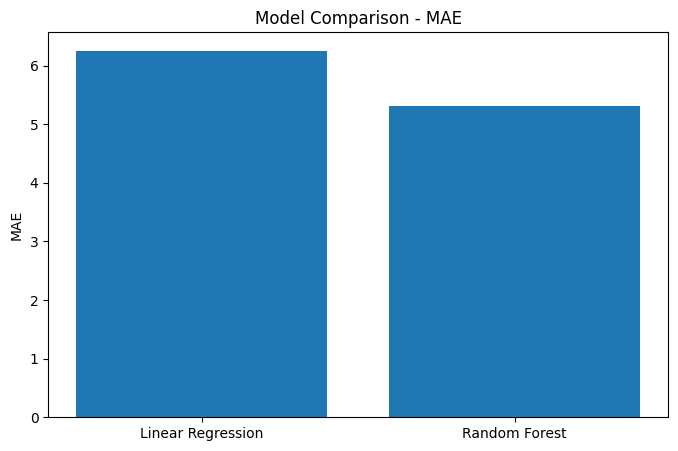

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["MAE"])

plt.title("Model Comparison - MAE")

plt.ylabel("MAE")

plt.show()

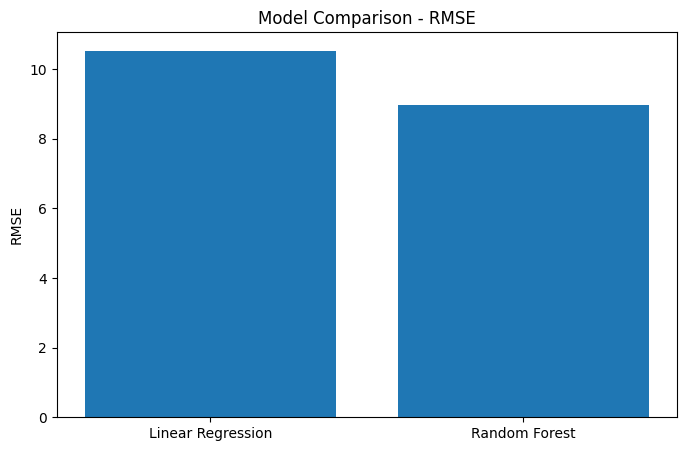

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison - RMSE")

plt.ylabel("RMSE")

plt.show()

-------------------------Importance des features RF---------------------------------

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

                      Feature  Importance
6             departure_delay    0.101060
2    scheduled_departure_time    0.091481
16            airport_traffic    0.082595
1                day_of_month    0.076287
11                        day    0.075909
3      scheduled_arrival_time    0.068724
4               flight_number    0.056313
5      scheduled_elapsed_time    0.045082
0                       month    0.044953
178                origin_JFK    0.038639
17            carrier_traffic    0.026428
35          unique_carrier_WN    0.022670
7                    distance    0.022593
190                origin_LGA    0.019611
14             departure_hour    0.012210
15               is_peak_hour    0.011017
128                origin_EWR    0.010203
524                  dest_ORD    0.006937
415                  dest_EWR    0.005582
244                origin_PHL    0.005507


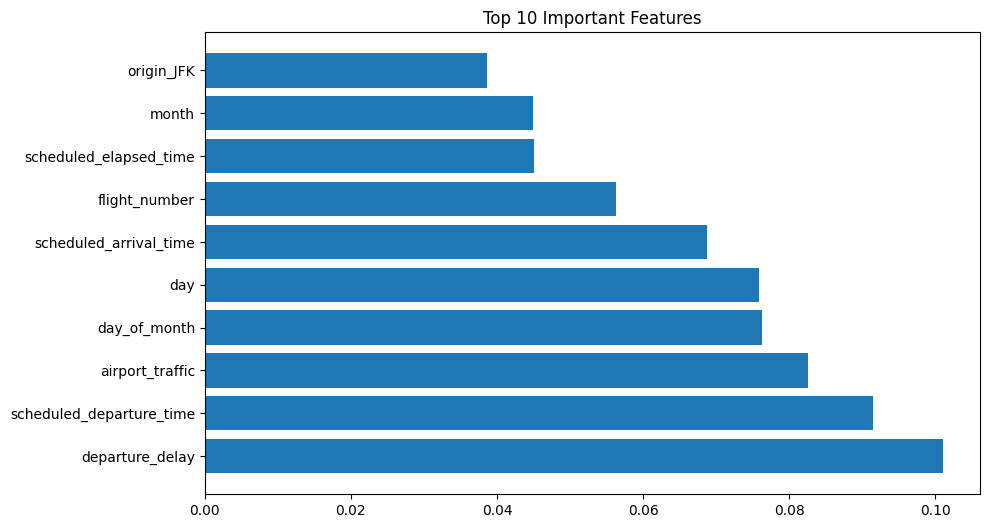

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")

plt.show()

-----------------------R carre score pour RF-------------------------------------

In [ ]:
lr_r2 = r2_score(y_test, y_pred)

rf_r2 = r2_score(y_test, rf_pred)

print("LR R2 :", lr_r2)

print("RF R2 :", rf_r2)

LR R2 : 0.2372146496706704
RF R2 : 0.44567563109092423


-------------------------COMPARAISON DE R carre ENTRE RL ET RF ------------------------------

               Model       MAE       RMSE        R2
0  Linear Regression  6.255295  10.532515  0.237215
1      Random Forest  5.306828   8.978688  0.445676


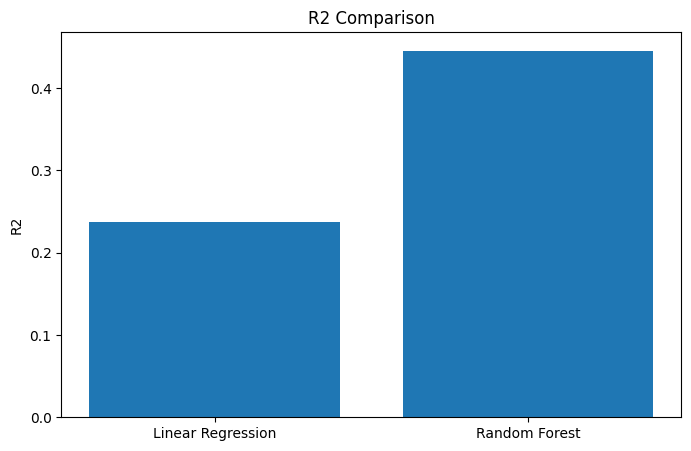

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

print(results)

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2"])

plt.title("R2 Comparison")

plt.ylabel("R2")

plt.show()

--------------------------ANALYSE DES ERREURS ----------------------------------------

In [ ]:
errors = abs(y_test - rf_pred)

print(errors.describe())

count    67803.000000
mean         5.306828
std          7.242596
min          0.000000
25%          1.570000
50%          3.450000
75%          6.430000
max        184.690000
Name: taxi_out, dtype: float64


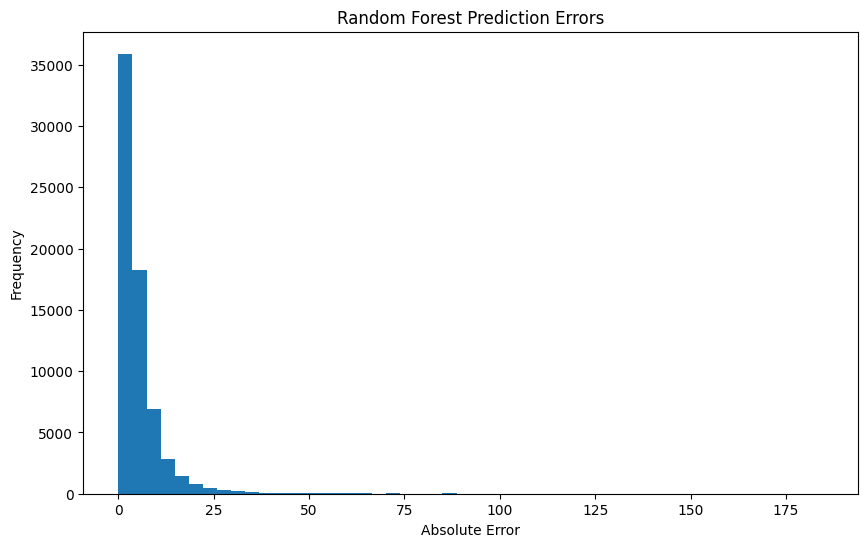

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(errors, bins=50)

plt.title("Random Forest Prediction Errors")

plt.xlabel("Absolute Error")

plt.ylabel("Frequency")

plt.show()

-------------------------------------------TOP ERREURS-----------------------------

In [ ]:
comparison = pd.DataFrame({
    "Real": y_test,
    "Predicted": rf_pred,
    "Error": errors
})

comparison = comparison.sort_values(
    by="Error",
    ascending=False
)

print(comparison.head(10))

         Real  Predicted   Error
183880  200.0      15.31  184.69
232331  176.0      25.54  150.46
11980   156.0      16.71  139.29
38956   163.0      27.10  135.90
264175  160.0      28.74  131.26
156759  199.0      68.43  130.57
156279  176.0      50.78  125.22
47446   143.0      18.53  124.47
292345  161.0      36.76  124.24
278507  151.0      26.99  124.01


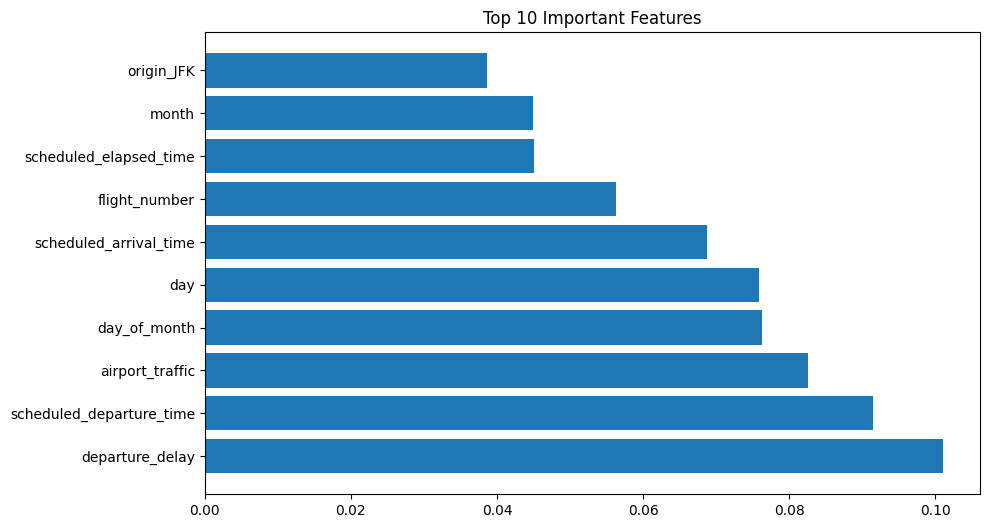

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")

plt.show()

//==================================================================================================================
                                           PHASE XGBOOST
//===================================================================================================================

-------------------------------CREATION DU MODELE-----------------------------------

In [ ]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

------------------------------------------TRAINER----------------------------------------------------

In [ ]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

--------------------------------------------PREDICTIONS----------------------------------

In [ ]:
xgb_pred = xgb.predict(X_test)

----------------------------------------METRIQUES---------------------------------------------------

In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_r2 = r2_score(y_test, xgb_pred)

----------------------------COMPARAISON--------------------------

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

print(results)

               Model       MAE       RMSE        R2
0  Linear Regression  6.255295  10.532515  0.237215
1      Random Forest  5.306828   8.978688  0.445676
2            XGBoost  5.835068   9.704853  0.352386


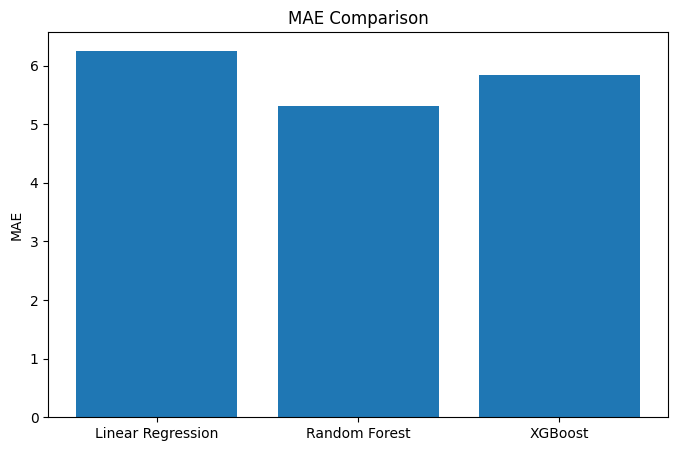

In [ ]:

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["MAE"])

plt.title("MAE Comparison")

plt.ylabel("MAE")

plt.show()

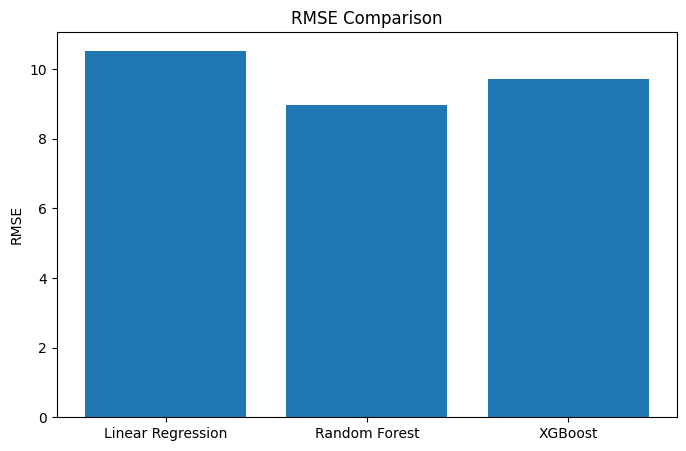

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.show()

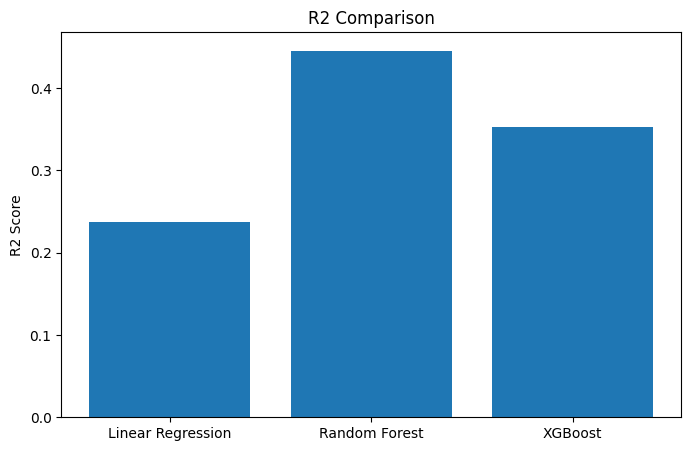

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2"])

plt.title("R2 Comparison")

plt.ylabel("R2 Score")

plt.show()

-------------------------------------DATAFRAME FEATURES  IMPORTANCES=---------------------------------------------------------------

In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})
xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance.head(15))

               Feature  Importance
178         origin_JFK    0.156901
190         origin_LGA    0.092019
16     airport_traffic    0.052033
113         origin_DEN    0.049086
128         origin_EWR    0.044834
17     carrier_traffic    0.031971
166         origin_IAH    0.018688
244         origin_PHL    0.017207
119         origin_DTW    0.013296
203         origin_MCO    0.013143
27   unique_carrier_FL    0.012481
37   unique_carrier_YV    0.011666
25   unique_carrier_EV    0.011281
282         origin_SFO    0.010821
15        is_peak_hour    0.010806


-------------------------------------VISUALISER---------------------------------------------

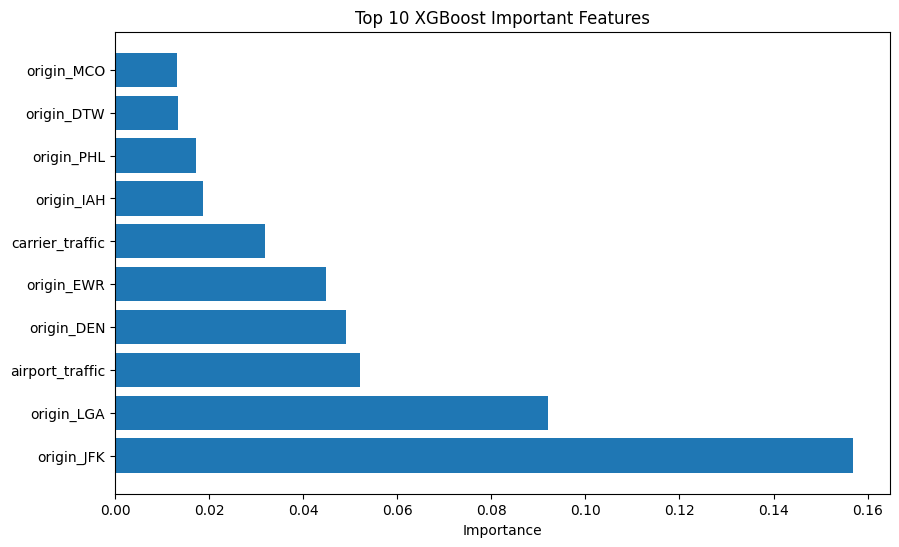

In [ ]:
top_features = xgb_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 XGBoost Important Features")

plt.xlabel("Importance")

plt.show()

---------------------------------ANALYSE DES ERREURS-----------------------------------------------------

count    67803.000000
mean         5.835068
std          7.754808
min          0.000103
25%          1.972978
50%          4.024677
75%          7.018432
max        182.282225
Name: absolute_error, dtype: float64


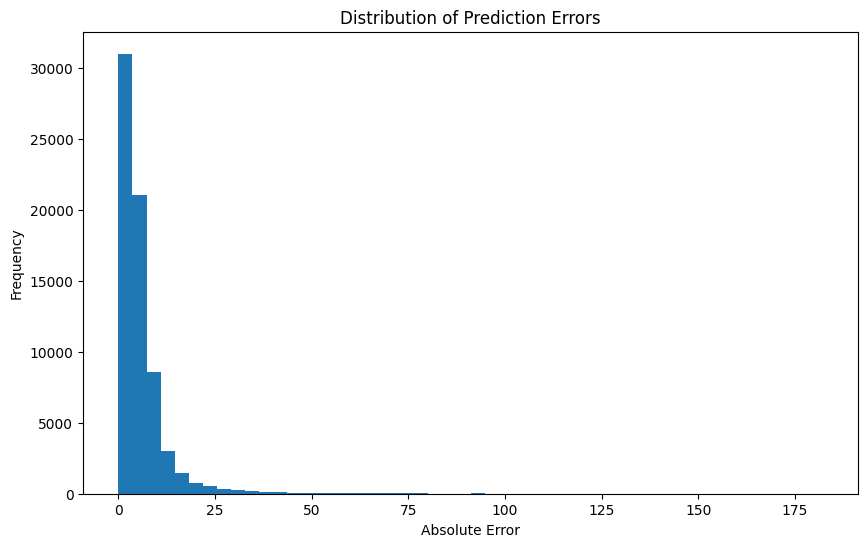

In [ ]:
analysis_df = X_test.copy()
analysis_df["real_taxi_out"] = y_test.values
analysis_df["predicted_taxi_out"] = xgb_pred
analysis_df["absolute_error"] = abs(
    analysis_df["real_taxi_out"]
    - analysis_df["predicted_taxi_out"]
)
print(analysis_df["absolute_error"].describe())
plt.figure(figsize=(10,6))

plt.hist(
    analysis_df["absolute_error"],
    bins=50
)

plt.title("Distribution of Prediction Errors")

plt.xlabel("Absolute Error")

plt.ylabel("Frequency")

plt.show()

In [ ]:
worst_predictions = analysis_df.sort_values(
    by="absolute_error",
    ascending=False
)

print(worst_predictions.head(10))

        month  day_of_month  scheduled_departure_time  scheduled_arrival_time  \
183880      3             7                       600                     766   
156759      2            22                       460                     667   
232331      3            21                       495                     545   
292345      4            11                      1201                    1296   
38956       1            11                       740                     881   
156279      2            22                       475                     835   
149827      2            22                       470                     661   
327527      4            25                      1050                    1132   
11980       1             4                      1330                    1380   
47446       1            18                       973                    1040   

        flight_number  scheduled_elapsed_time  departure_delay  distance  \
183880           5643           

------------------------------PEAK HOUR------------------------------------------------------

is_peak_hour
0    5.908808
1    5.668872
Name: absolute_error, dtype: float64


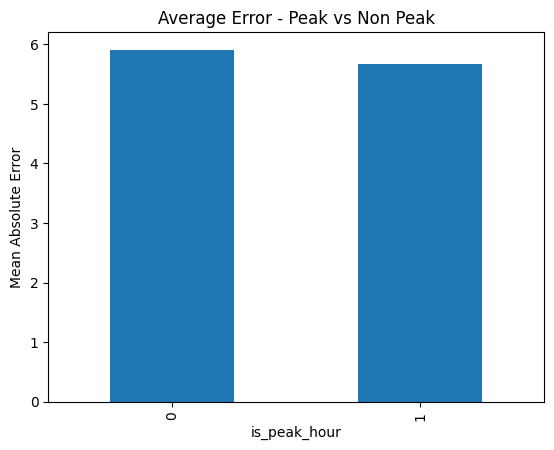

In [ ]:
peak_error = analysis_df.groupby(
    "is_peak_hour"
)["absolute_error"].mean()

print(peak_error)
peak_error.plot(kind="bar")

plt.title("Average Error - Peak vs Non Peak")

plt.ylabel("Mean Absolute Error")

plt.show()

----------------------------------------------------HYPERPARAMETER TUNING---------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------

MODEL DE BASE

In [ ]:
xgb_model = XGBRegressor(
    random_state=42
)

In [ ]:
param_grid = {
    
    "n_estimators": [50, 100],
    
    "max_depth": [4, 6],
    
    "learning_rate": [0.05, 0.1]
}
grid_search = GridSearchCV(
    
    estimator=xgb_model,
    
    param_grid=param_grid,
    
    scoring="neg_mean_absolute_error",
    
    cv=3,
    
    verbose=2,
    
    n_jobs=-1
)

-----------------------------TRAINING GRID SEARCH------------------------------------

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [4, 6], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [ ]:
print(grid_search.best_params_)

{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


MEILLEUR MODEL

In [ ]:
best_xgb = grid_search.best_estimator_

PREDICTION

In [ ]:
best_pred = best_xgb.predict(X_test)

METRIQUES

In [ ]:
best_mae = mean_absolute_error(
    y_test,
    best_pred
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_pred
    )
)

best_r2 = r2_score(
    y_test,
    best_pred
)

In [ ]:
print("Tuned XGBoost")

print("MAE :", best_mae)

print("RMSE :", best_rmse)

print("R2 :", best_r2)

Tuned XGBoost
MAE : 5.835068165048966
RMSE : 9.704853243921637
R2 : 0.3523861811861847
